# Import dask and set up client for resource dashboard

In [ ]:
from dask import dataframe as dd
from dask.distributed import Client # only for dashboard

client = Client() # only for dashboard
print(client.dashboard_link) # only for dashboard

# Read JSON dataset

In [2]:
df = dd.read_json("arxiv-metadata-oai-snapshot-v282.json", blocksize="16MB", dtype={"id": "string"}) # ID gets read as a float otherwise
df["update_date"] = dd.to_datetime(df["update_date"], format="%Y-%m-%d")

In [3]:
print(df.dtypes)

id                        string
submitter                 string
authors                   string
title                     string
comments                  string
journal-ref               string
doi                       string
report-no                 string
categories                string
license                   string
abstract                  string
versions                  string
update_date       datetime64[us]
authors_parsed            string
dtype: object


# Total paper count vs. only papers published on and after 2019-01-01

In [ ]:
total_len = len(df)
print(f'Total paper count: {total_len}')

since_2019_len = len(df[df['update_date'] >= '2019-01-01'])
print(f"Paper count from 2019-01-01 onwards: {since_2019_len}")


# Earliest and latest date

In [5]:
min_date = df.update_date.min().compute()
max_date = df.update_date.max().compute()

print(f'Entries from date {min_date.strftime("%Y-%m-%d")} to {max_date.strftime("%Y-%m-%d")}')

Entries from date 2007-05-23 to 2026-04-17


# Top 10 authors

In [ ]:
top_authors = df.authors.value_counts().nlargest(10).compute()
print('Top 10 authors by paper count:')
print(top_authors)


Top 10 authors by paper count:
authors
CMS Collaboration                            1455
ATLAS Collaboration                          1362
ALICE Collaboration                           560
The BABAR Collaboration, B. Aubert, et al     263
Lorenzo Iorio                                 241
Saharon Shelah                                234
Shahar Hod                                    200
Miloslav Znojil                               186
Stefano Longhi                                162
G.E. Volovik                                  161
Name: count, dtype: int64[pyarrow]


# Top categories

In [7]:
import pandas as pd

counts = (
    df["categories"]
    .str.split()
    .explode()
    .value_counts()
    .compute()
    .sort_values(ascending=False)
)

print(f"Total unique categories: {len(counts)}")

print("Paper count per category:")
with pd.option_context("display.max_rows", None):
    display(counts)

Total unique categories: 176
Paper count per category:


categories
cs.LG                 261782
hep-ph                195304
cs.CV                 189049
hep-th                181522
quant-ph              177607
cs.AI                 172727
gr-qc                 120906
cond-mat.mtrl-sci     108115
cs.CL                 106724
astro-ph              105380
cond-mat.mes-hall     100681
math.MP                89244
math-ph                89244
cond-mat.str-el        82318
cond-mat.stat-mech     80969
math.CO                77466
stat.ML                76902
astro-ph.GA            76638
astro-ph.CO            76444
math.AP                73319
astro-ph.SR            68885
astro-ph.HE            68269
math.PR                65102
nucl-th                62199
math.OC                60669
hep-ex                 59820
math.AG                59051
physics.optics         55638
math.IT                53893
cs.IT                  53893
cs.RO                  51916
math.NT                48505
math.DG                47401
cs.CR                  47277
mat

# Top terms in titles/abstracts

## Required imports and creation of stop words list

In [ ]:
import nltk
from sklearn.feature_extraction.text import CountVectorizer

nltk.download('stopwords')
stop_words = nltk.corpus.stopwords.words('english')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/azureuser/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Get top bi/trigrams in titles and abstracts

In [18]:
# Set this to how many top n-grams to find in titles and abstracts
top_ngram_count = 10

In [19]:
title_vectorizer = CountVectorizer(analyzer='word', stop_words=stop_words, ngram_range=(2, 3)) # automatically lowercases
BoW_title = title_vectorizer.fit_transform(df.title.compute())

# get the top_ngram_count most common words in titles
title_word_counts = BoW_title.sum(axis=0).A1
title_vocab = title_vectorizer.get_feature_names_out()
top_title_indices = title_word_counts.argsort()[-top_ngram_count:][::-1]

print(f'Top {top_ngram_count} words in titles:')
for idx in top_title_indices:
    print(f'{title_vocab[idx]}: {title_word_counts[idx]}')

/home/azureuser/.local/lib/python3.13/site-packages/dask/dataframe/io/json.py:299: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = engine(s, orient="records", lines=True, **kwargs)
/home/azureuser/.local/lib/python3.13/site-packages/dask/dataframe/io/json.py:299: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = engine(s, orient="records", lines=True, **kwargs)


Top 10 words in titles:
language models: 23560
neural networks: 23015
dark matter: 20038
black hole: 18727
machine learning: 18277
reinforcement learning: 18172
large language: 17672
deep learning: 17535
two dimensional: 16606
black holes: 16141


In [20]:
abstract_vectorizer = CountVectorizer(analyzer='word', stop_words=stop_words, ngram_range=(2, 3))
BoW_abstract = abstract_vectorizer.fit_transform(df.abstract.compute())

# get the top_ngram_count most common words in abstracts
abstract_word_counts = BoW_abstract.sum(axis=0).A1
abstract_vocab = abstract_vectorizer.get_feature_names_out()
top_abstract_indices = abstract_word_counts.argsort()[-top_ngram_count:][::-1]

print(f'Top {top_ngram_count} words in abstracts:')
for idx in top_abstract_indices:
    print(f'{abstract_vocab[idx]}: {abstract_word_counts[idx]}')

Top 10 words in abstracts:
state art: 182513
magnetic field: 118687
real world: 115061
machine learning: 106210
large scale: 100456
black hole: 99091
neural networks: 90283
results show: 90091
dark matter: 88657
language models: 86661


## Render wordclouds for top title/abstracts terms

In [21]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

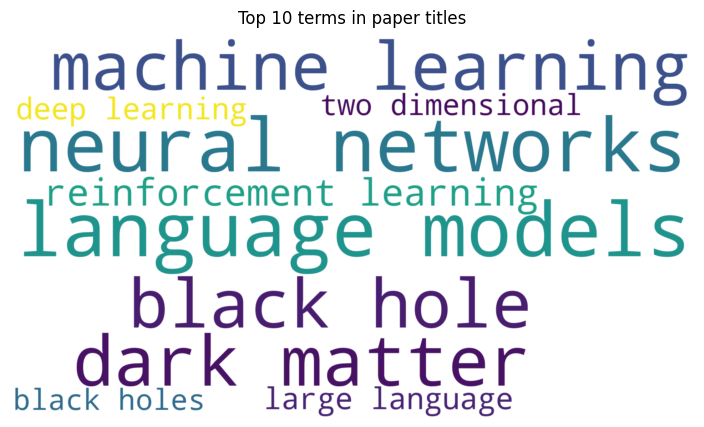

In [22]:
top_title_words={title_vocab[idx]: title_word_counts[idx] for idx in top_title_indices}
wordcloud=WordCloud(width=1920, height=1080, background_color="white").generate_from_frequencies(top_title_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title(f'Top {top_ngram_count} terms in paper titles')
plt.savefig(f'artifacts/EDA/top_{top_ngram_count}_title_terms.png', dpi=300, bbox_inches='tight')
plt.show()

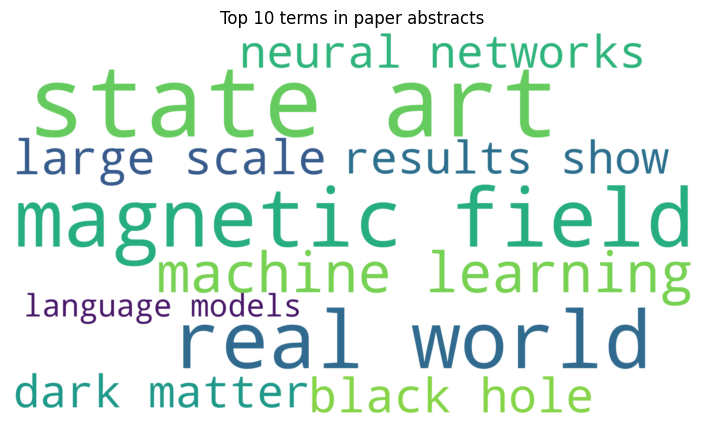

In [23]:
top_abstract_words={abstract_vocab[idx]: abstract_word_counts[idx] for idx in top_abstract_indices}
wordcloud=WordCloud(width=1920, height=1080, background_color="white").generate_from_frequencies(top_abstract_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title(f'Top {top_ngram_count} terms in paper abstracts')
plt.savefig(f'artifacts/EDA/top_{top_ngram_count}_abstract_terms.png', dpi=300, bbox_inches='tight')
plt.show()

# Run optionally to shutdown Dask client

In [15]:
client.close()